In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

/home/ubuntu/miniconda3/envs/exploratory_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.append("../../config")
import experiment_config

In [3]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [4]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

In [5]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [6]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = experiment_config.device
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")

In [7]:
esm_fine_tuned = interp_utils.get_model()

In [8]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [9]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [10]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [11]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [12]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = interp_utils.get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(interp_utils.get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [13]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [14]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [15]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [16]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [17]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [18]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4498
torch.Size([4498, 1024])


In [19]:
hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = interp_utils.add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [20]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [21]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = interp_utils.get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [22]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [23]:
logit_id = original_task_id_infos["fitness_USA"]

# Curating new fitness with low-mutation dataset

# F456L mutation (from Eta clades)

In [24]:
eta_seqs = [all_uniq_seqs[seq_idxs[i]] for i,n in enumerate(seq_names) if "(Eta)" in name_to_clade_dict[n]]
eta_names = [n for n in seq_names if "(Eta)" in name_to_clade_dict[n]]

uniq_eta_seqs, unique_eta_inv_idx  = np.unique(eta_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences

In [25]:
# F456L mutation 
N = 456

eta_orig_seq_idx = [i for i,x in enumerate(uniq_eta_seqs) if x[N-1] == "F"]

eta_orig_idx = [x for x in uniq_eta_seqs if x[N-1] == "F"][:80]
eta_new_idx = [x[:N-1] + "L" + x[N:] for x in eta_orig_idx]

In [26]:
eta_orig_toks = tokenizer(eta_orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
eta_new_toks = tokenizer(eta_new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [27]:
eta_orig_output = get_logit_hooked(hooked_esm(eta_orig_toks), logit_id)
torch.cuda.empty_cache()
eta_new_output = get_logit_hooked(hooked_esm(eta_new_toks), logit_id)
torch.cuda.empty_cache()

In [28]:
diffs = (eta_new_output - eta_orig_output).cpu().numpy()
print(diffs.mean())

0.00082859566


# F456L mutation (from XBB clades)

In [29]:
xbb_seqs = [all_uniq_seqs[seq_idxs[i]] for i,n in enumerate(seq_names) if "(XBB.1.5)" in name_to_clade_dict[n]]
xbb_names = [n for n in seq_names if "(XBB.1.5)" in name_to_clade_dict[n]]

uniq_xbb_seqs, unique_xbb_inv_idx  = np.unique(xbb_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences

In [30]:
# F456L mutation 
N = 456

orig_seq_idx = [i for i,x in enumerate(uniq_xbb_seqs) if x[N-1] == "F"]

orig_idx = [x for x in uniq_xbb_seqs if x[N-1] == "F"][:80]
new_idx = [x[:N-1] + "L" + x[N:] for x in orig_idx]

In [31]:
orig_toks = tokenizer(orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
new_toks = tokenizer(new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [32]:
orig_output = get_logit_hooked(hooked_esm(orig_toks), logit_id)
torch.cuda.empty_cache()
new_output = get_logit_hooked(hooked_esm(new_toks), logit_id)
torch.cuda.empty_cache()

In [33]:
diffs = (new_output - orig_output).cpu().numpy()

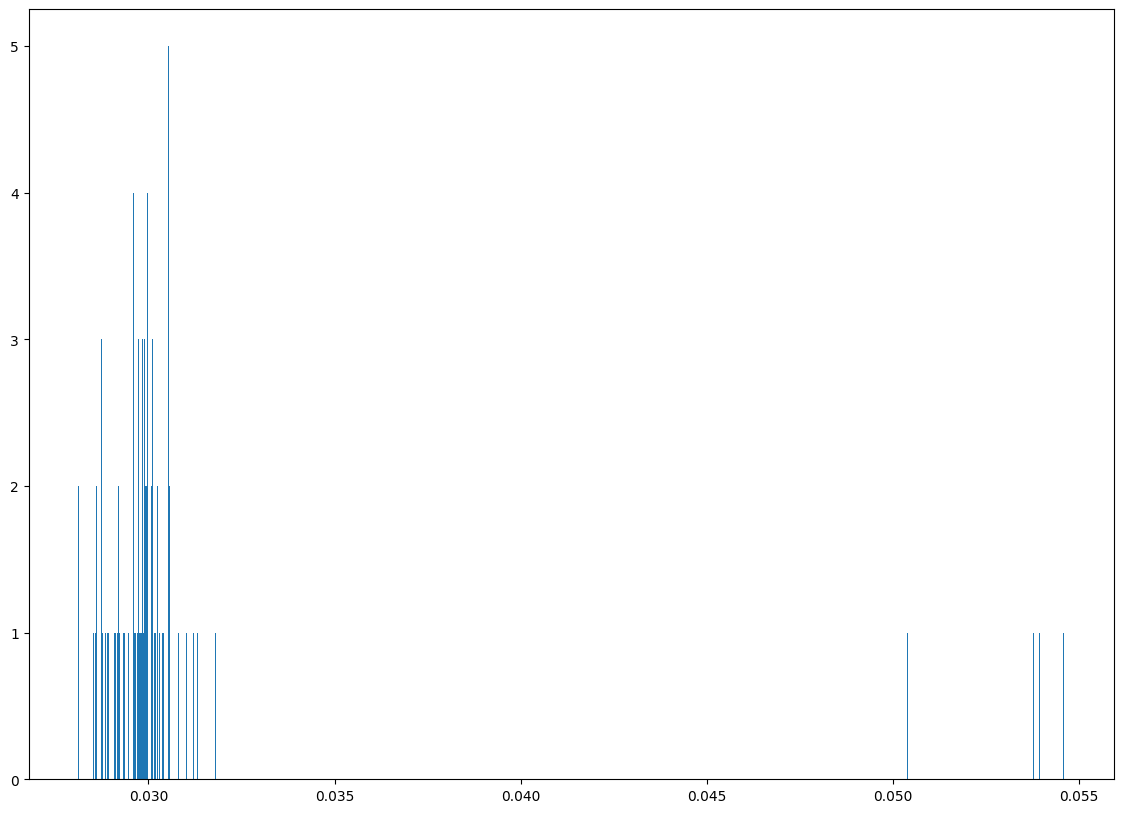

In [34]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.hist(diffs, bins=1000)
# ax.set_xlim([0,0.04])
plt.show()

# recreating plots

In [33]:
resid_component_names = ["blocks.0.hook_resid_pre"]
for layer in range(hooked_esm.cfg.n_layers):
    resid_mid_name = f"blocks.{layer}.hook_resid_mid"
    resid_post_name = f"blocks.{layer}.hook_resid_post"
    resid_component_names.append(resid_mid_name)
    resid_component_names.append(resid_post_name)
    
def patch_resid_direct_to_regressor(toks: Float[Tensor, "n_data d_vocab"], model, logit_id=logit_id, resid_component_names=resid_component_names):
    n_data = toks.size(0)
    _, resid_cache = model.run_with_cache(toks, names_filter=resid_component_names)
    torch.cuda.empty_cache()

    logit_results = torch.zeros(n_data, len(resid_component_names)).to(device) #[n_data n_components]
    final_ln = model.ln_final

    # run regressor model on residual stream at each layer (including before attn0 and after final layer norm)
    for i, component in enumerate(resid_component_names):
        resid_component = final_ln(resid_cache[component])
        logit_results[:, i] = get_logit_hooked(resid_component, tok_id=logit_id)

    return logit_results

In [34]:
high_resid_layer_results = patch_resid_direct_to_regressor(new_toks, hooked_esm)
torch.cuda.empty_cache()
low_resid_layer_results = patch_resid_direct_to_regressor(orig_toks, hooked_esm)
torch.cuda.empty_cache()

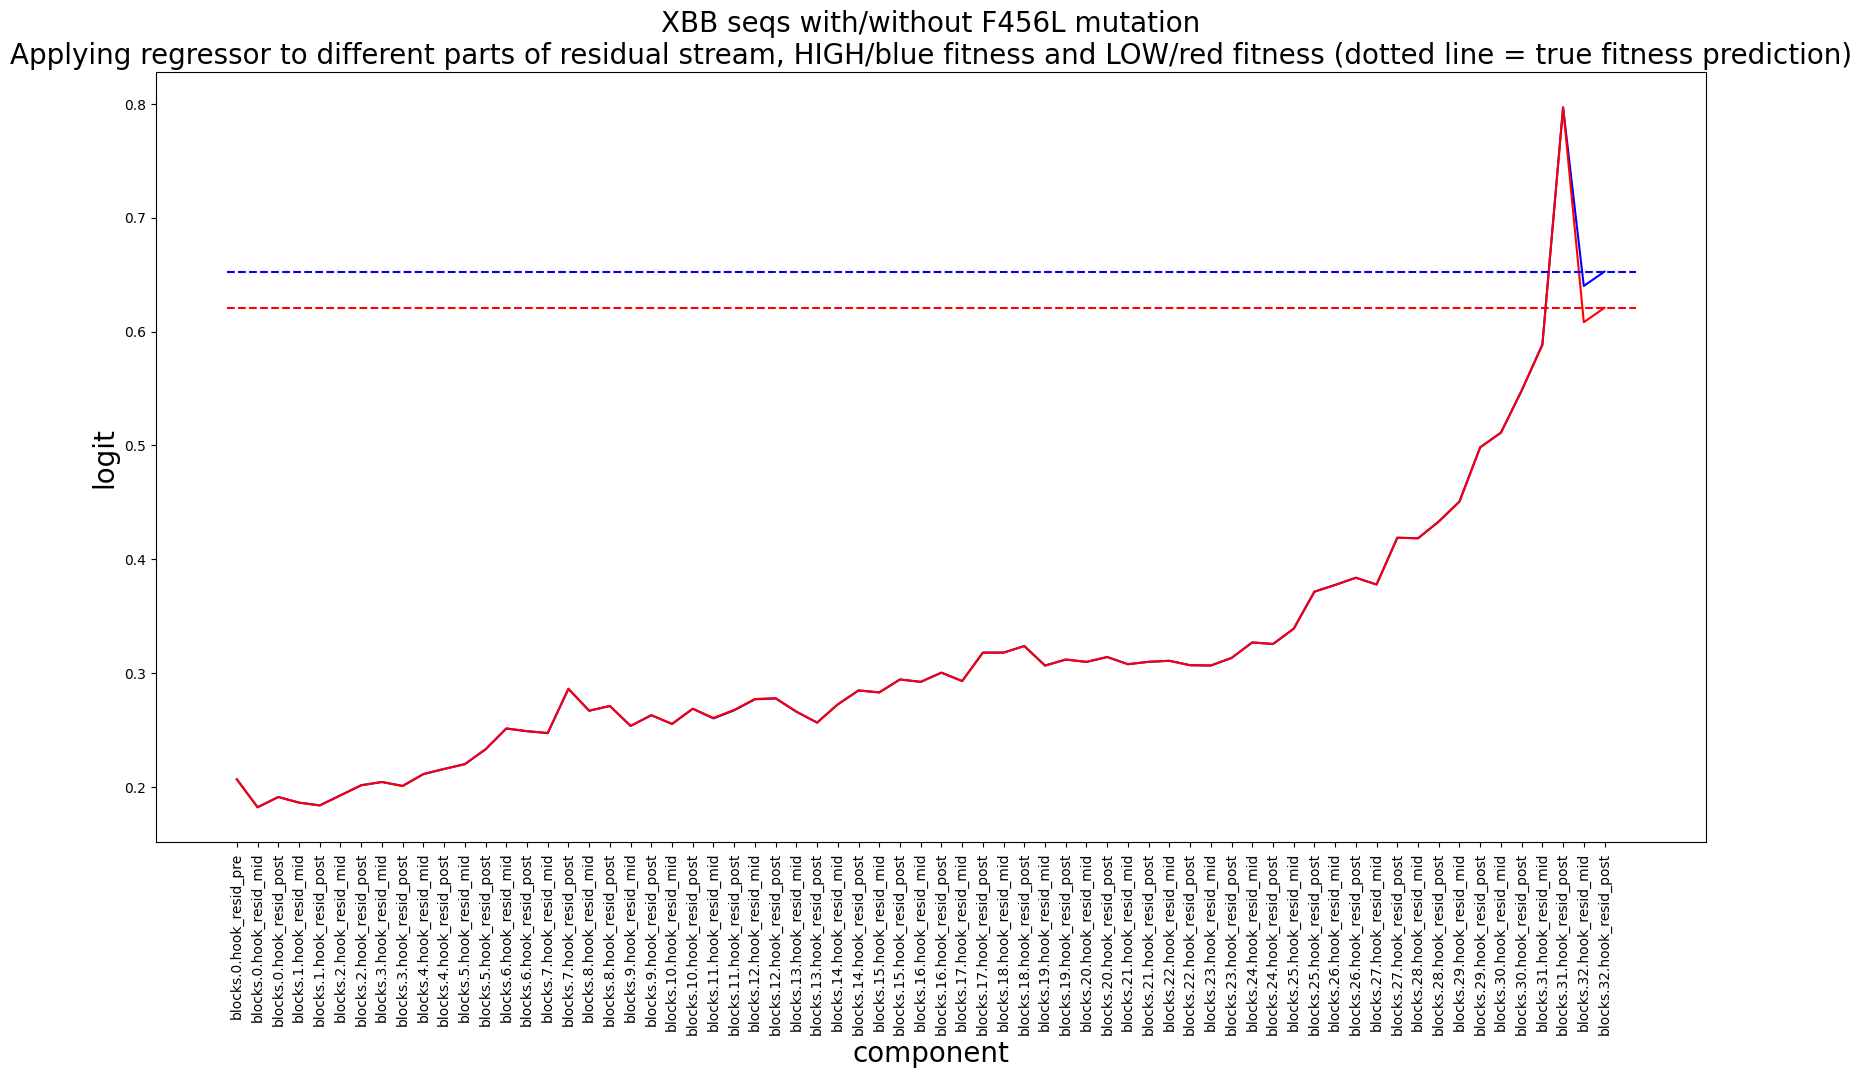

In [35]:
# display results
fig, ax = plt.subplots(1,1,figsize=(20,10))
ax.plot(list(range(len(resid_component_names))), high_resid_layer_results.mean(dim=0).cpu().numpy(), color="blue")
ax.plot(list(range(len(resid_component_names))), low_resid_layer_results.mean(dim=0).cpu().numpy(), color="red")

ax.plot([-0.5, len(resid_component_names)+0.5], [high_resid_layer_results[:,-1].cpu().mean()for _ in range(2)], linestyle="dashed", color="blue")
ax.plot([-0.5, len(resid_component_names)+0.5], [low_resid_layer_results[:,-1].cpu().mean() for _ in range(2)], linestyle="dashed", color="red")

ax.set_title("XBB seqs with/without F456L mutation\nApplying regressor to different parts of residual stream, HIGH/blue fitness and LOW/red fitness (dotted line = true fitness prediction)", fontsize=20)
ax.set_xticks(list(range(len(resid_component_names))), resid_component_names, rotation="vertical")
ax.set_xlabel("component", fontsize=20)
ax.set_ylabel("logit", fontsize=20)
plt.show()

In [36]:
# clean up things
del high_resid_layer_results
del low_resid_layer_results
torch.cuda.empty_cache()

# Path Patching

In [31]:
# path patching metric 
def path_patching_metric(
    logits: Float[Tensor, "batch"],
    corrupted_logit_mean: float,
    clean_logit_mean: float,
):
    """
    Equals 0 when performance is conserved (i.e. high fitness sequences still high fitness)
    Equals -1 when performance is destroyed (high fitness sequence is degraded)
    """

    return ((logits - clean_logit_mean) / (clean_logit_mean - corrupted_logit_mean)).mean().item()

In [32]:
hooked_esm.reset_hooks(including_permanent=False)
# clean = high fitness
# corr = low fitness

clean_toks = new_toks
corr_toks = orig_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.031743526458740234


In [39]:
patched_head_output_comps = []
for receiver_input in ["k", "q", "v", "z", "pattern"]:
    if receiver_input == "pattern":
        _, corrupted_cache = hooked_esm.run_with_cache(corr_toks, names_filter = lambda x: ("hook_q" in x) or ("hook_k" in x))
        torch.cuda.empty_cache()
    else:
        _, corrupted_cache = hooked_esm.run_with_cache(corr_toks, names_filter = lambda x: f"hook_{receiver_input}" in x)
        torch.cuda.empty_cache()

    patched_head_output = interp_utils.get_act_patch_attn_head_out_all_pos(
        hooked_esm, 
        logit_id=logit_id, 
        clean_tokens=clean_toks, 
        corrupted_cache=corrupted_cache,
        receiver_input=receiver_input,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        get_logit_hooked=get_logit_hooked
    )

    patched_head_output_comps.append(patched_head_output)
    torch.cuda.empty_cache()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [21:19<00:00,  1.94s/it]


In [40]:
patched_head_output_tensor = torch.stack(patched_head_output_comps, dim=0)
# patched_head_output_tensor = torch.permute(patched_head_output_tensor, (0,2,1))

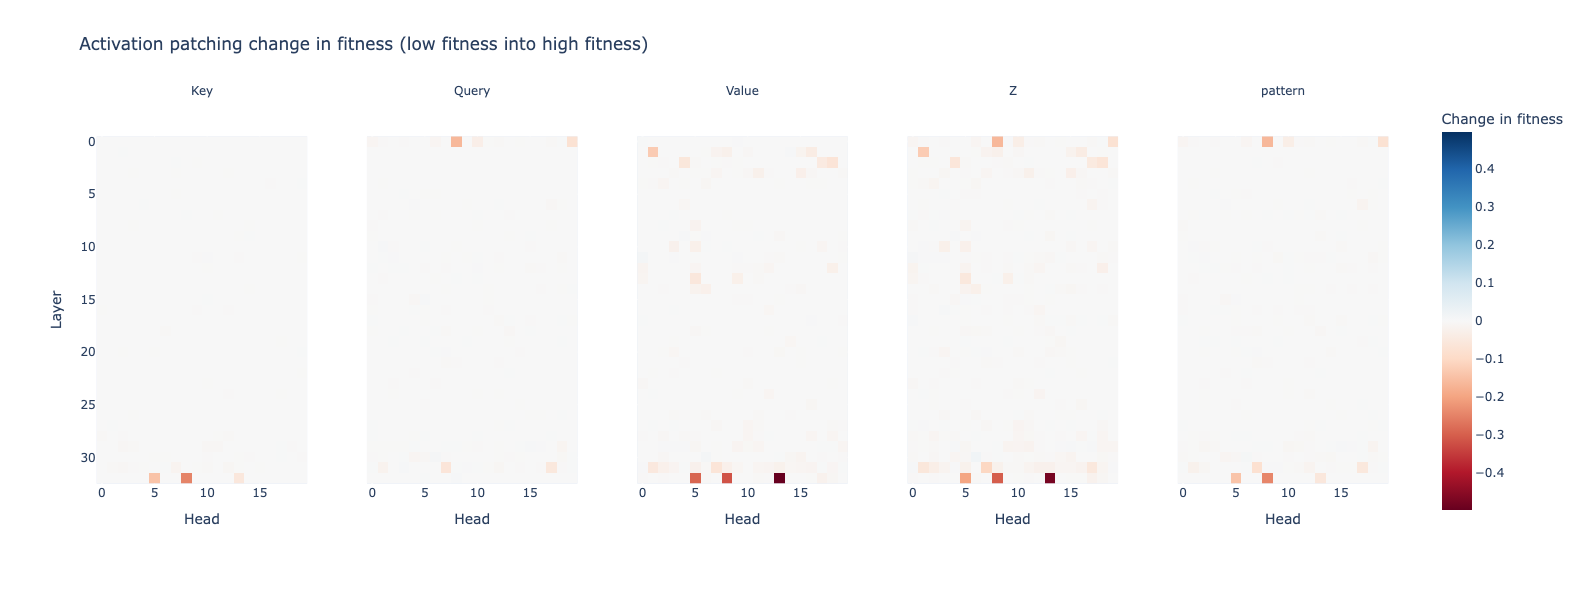

In [41]:
imshow(
    patched_head_output_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Activation patching change in fitness (low fitness into high fitness)",
    width=1400,
    height=600,
    facet_labels=["Key", "Query", "Value", "Z", "pattern"],
    facet_col=0,
    # range_color=(-0.8,0.8)
)

In [42]:
mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

In [43]:
_, corrupted_cache = hooked_esm.run_with_cache(corr_toks, names_filter = mlp_names)
torch.cuda.empty_cache()

In [44]:
patched_mlp_output = interp_utils.get_act_patch_mlp_all_pos(
    hooked_esm, 
    logit_id=logit_id, 
    clean_tokens=clean_toks, 
    corrupted_cache=corrupted_cache,
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    get_logit_hooked=get_logit_hooked
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [01:04<00:00,  1.94s/it]


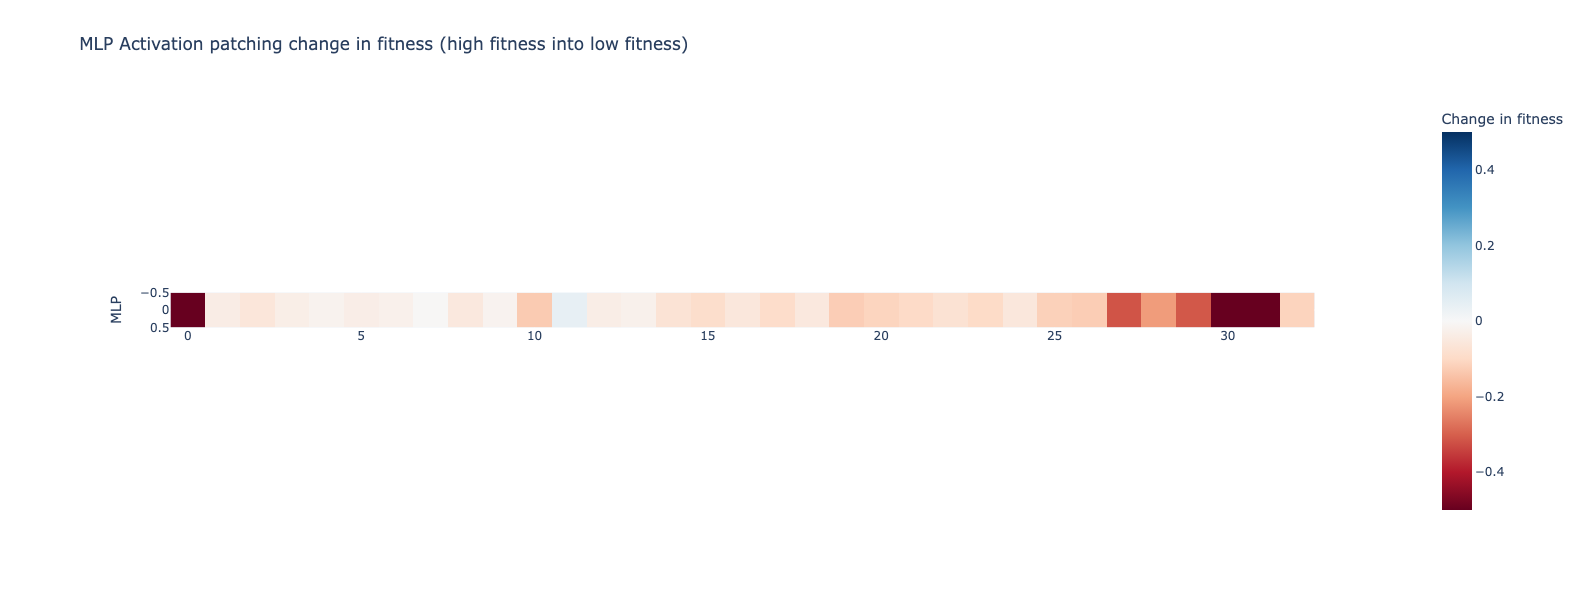

In [45]:
imshow(
    patched_mlp_output.T,
    labels={"x": "", "y": "MLP", "color": "Change in fitness"},
    title="MLP Activation patching change in fitness (high fitness into low fitness)",
    width=1400,
    height=600,
    range_color=(-0.5,0.5)
)

In [47]:
hooked_esm.reset_hooks(including_permanent=False)
# clean = high fitness
# corr = low fitness

clean_toks = new_toks
corr_toks = orig_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.031743526458740234


In [48]:
# only need attention info
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [49]:
abs_patch_head = interp_utils.path_patch_head_absolute_direct(
    hooked_esm, 
    orig_dataset=clean_toks, 
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    new_cache=new_cache,
    logit_id=logit_id,
    get_logit_hooked=get_logit_hooked
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [00:04<00:00, 161.86it/s]


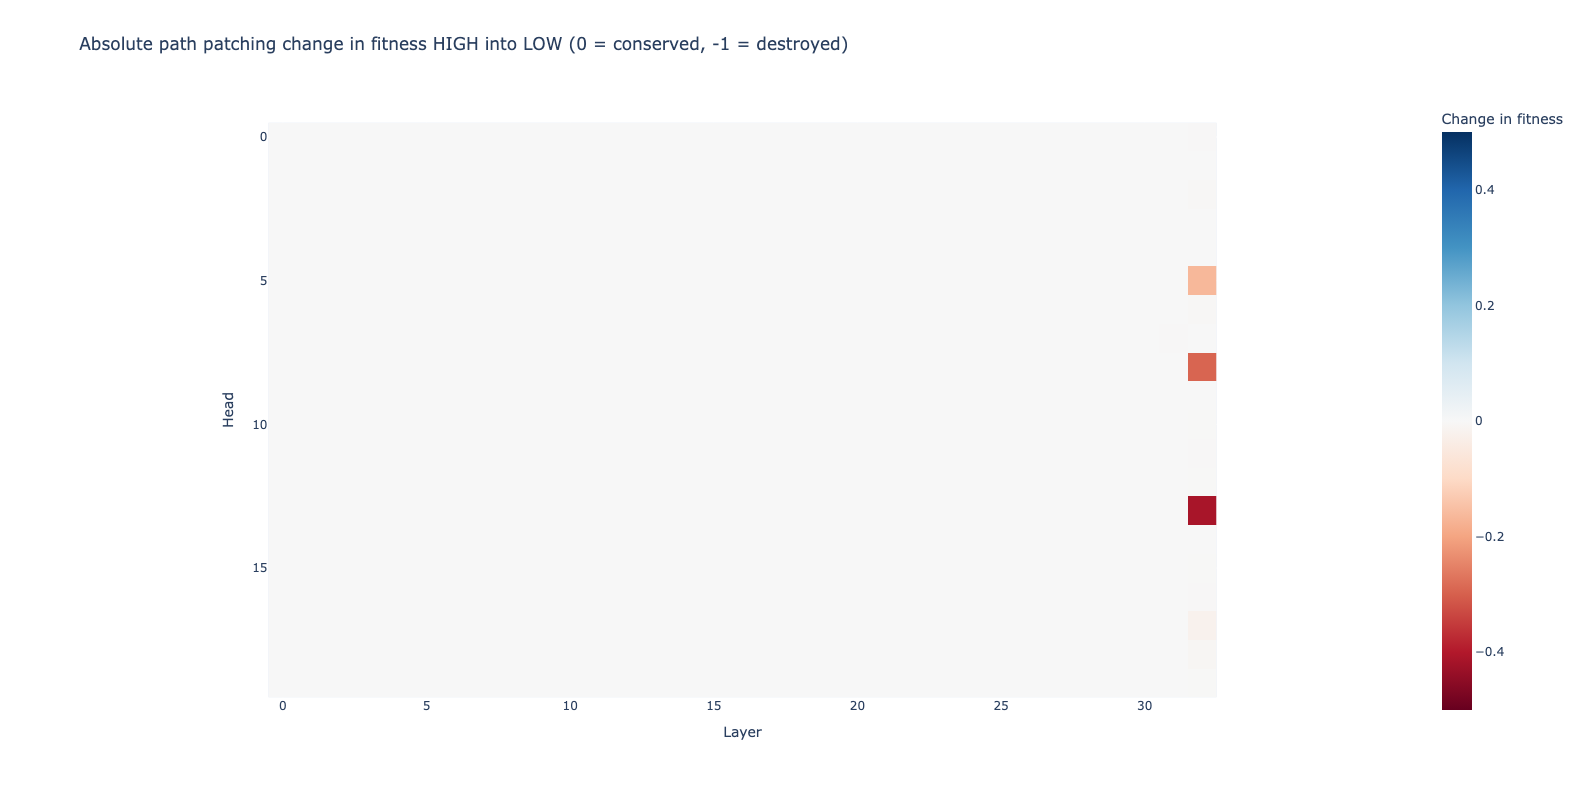

In [50]:
imshow(
    abs_patch_head.T,
    labels={"x": "Layer", "y": "Head", "color": "Change in fitness"},
    title="Absolute path patching change in fitness HIGH into LOW (0 = conserved, -1 = destroyed)",
    width=1200,
    height=800,
    range_color=(-0.5,0.5)
)

In [33]:
all_mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]
# only need mlp info
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()

In [34]:
absolute_path_patch_mlp_results = interp_utils.path_patch_mlp_absolute_direct(
    hooked_esm,
    orig_dataset=clean_toks,
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    new_cache=new_cache,
    logit_id=logit_id,
    get_logit_hooked=get_logit_hooked
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:00<00:00, 306.74it/s]


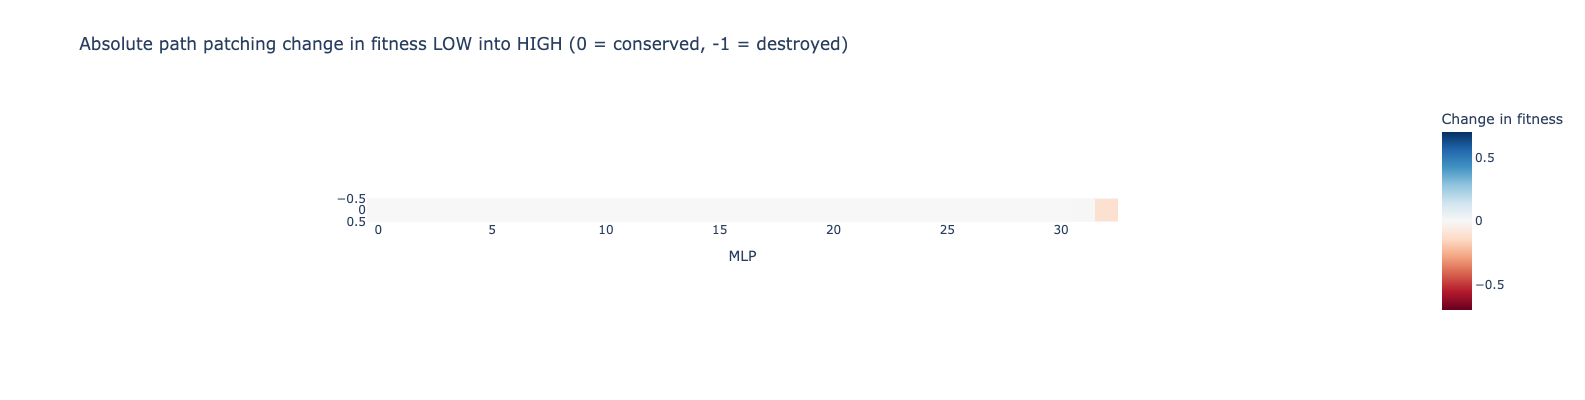

In [35]:
imshow(
    absolute_path_patch_mlp_results[None,:],
    labels={"x": "MLP", "y": "", "color": "Change in fitness"},
    title="Absolute path patching change in fitness LOW into HIGH (0 = conserved, -1 = destroyed)",
    width=1000,
    height=400,
    range_color=(-0.7,0.7)
)

In [32]:
# original = high fitness
# new = low fitness
clean_toks = new_toks
corr_toks = orig_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

-0.0318608283996582


In [33]:
path_patch_32_5_8_13_qkv = []
for receiver_input in ["k","q","v"]:
    path_patch_32_5_8_13 = interp_utils.get_path_patch_head_to_heads(
        hooked_esm, 
        receiver_heads=[(32,5), (32,8), (32,13)], 
        receiver_input=receiver_input, # changing the output "z" of head 31.7 has the strongest direct affect on the logits, so that's what we will be patch-patching into 
        new_dataset=corr_toks,
        orig_dataset=clean_toks,
        patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id,
        get_logit_hooked=get_logit_hooked
    )
    path_patch_32_5_8_13_qkv.append(path_patch_32_5_8_13)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [42:45<00:00,  3.89s/it]


In [34]:
path_patch_32_5_8_13_tensor = torch.stack(path_patch_32_5_8_13_qkv, dim=0)

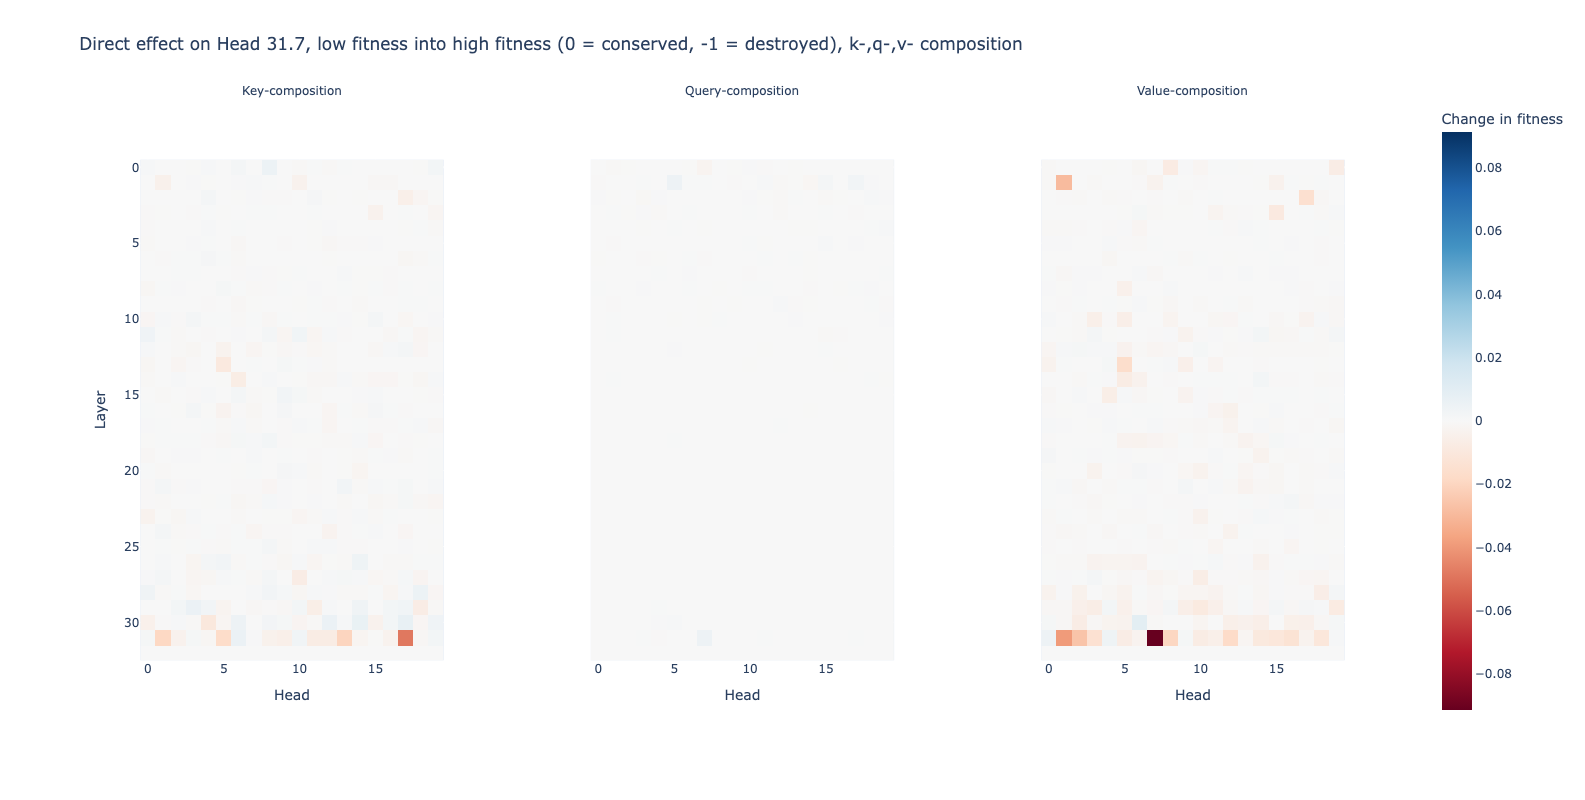

In [35]:
imshow(
    path_patch_32_5_8_13_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Direct effect on Head 31.7, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Key-composition", "Query-composition", "Value-composition"],
    width=1200,
    height=800,
    facet_col=0,
    # range_color=(-1,1)
)

In [44]:
hooked_esm.reset_hooks(including_permanent=False)
# clean = high fitness
# corr = low fitness

clean_toks = new_toks
corr_toks = orig_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.0318608283996582


In [45]:
# only need attention info
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [47]:
all_abs_patch_32_8_5_13_results = []
for receiver_input in ["q", "k", "v"]:
    abs_patch_32_8_5_13 = interp_utils.abs_path_patch_receiver_heads(
        model=hooked_esm,
        receiver_heads = [(32,5), (32,8), (32,13)], # (layer,head)
        receiver_input = receiver_input, #one of {"q", "k", "v"}
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache = new_cache, # cached attn. z
        orig_cache = orig_cache, # cached attn. z
        get_logit_hooked=get_logit_hooked,
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    all_abs_patch_32_8_5_13_results.append(abs_patch_32_8_5_13)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 640/640 [20:42<00:00,  1.94s/it]


In [48]:
all_abs_patch_32_8_5_13_results_tensor = torch.stack(all_abs_patch_32_8_5_13_results, dim=0)

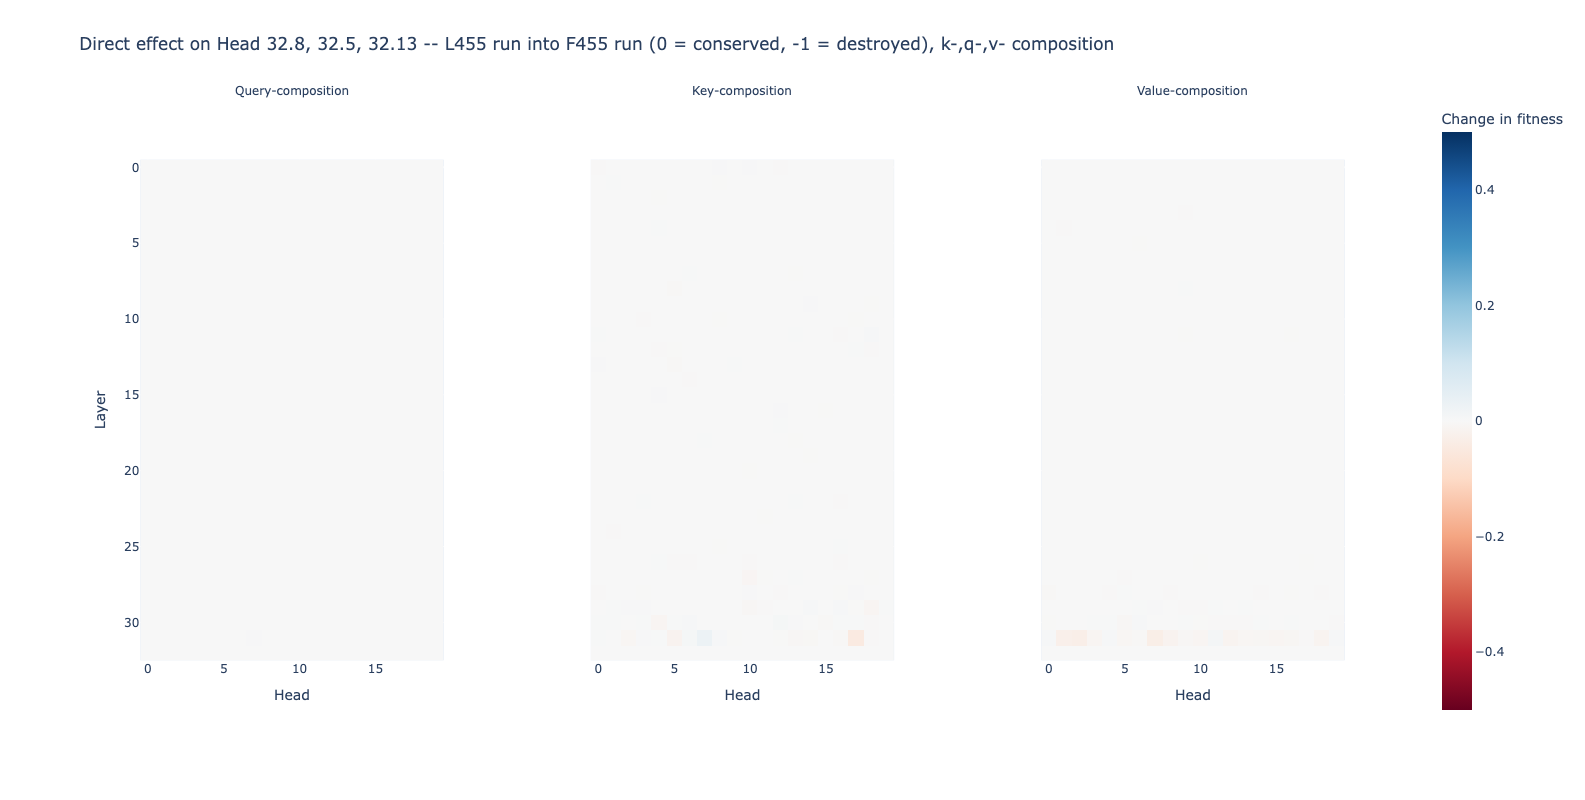

In [59]:
imshow(
    all_abs_patch_32_8_5_13_results_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Direct effect on Head 32.8, 32.5, 32.13 -- L455 run into F455 run (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=["Query-composition", "Key-composition", "Value-composition"],
    width=1200,
    height=800,
    facet_col=0,
    range_color=(-0.5,0.5)
)

In [36]:
hooked_esm.reset_hooks(including_permanent=False)
torch.cuda.empty_cache()

In [37]:
mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]

In [38]:
# cache MLP outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=mlp_names)
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=mlp_names)
torch.cuda.empty_cache()

In [39]:
all_abs_mlp_patch_32_5_8_13_results = []
for receiver_input in ["q", "k", "v"]:
    abs_mlp_patch_32_5_8_13 = interp_utils.abs_path_patch_mlp_to_receiver_heads(
        model=hooked_esm,
        receiver_heads = [(32,5), (32,8), (32,13)], # (layer,head)
        receiver_input = receiver_input, #one of {"q", "k", "v"}
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache = new_cache, # cached attn. mlp
        orig_cache = orig_cache, # cached attn. mlp
        get_logit_hooked=get_logit_hooked,
        logit_id=logit_id
    )
    torch.cuda.empty_cache()
    all_abs_mlp_patch_32_5_8_13_results.append(abs_mlp_patch_32_5_8_13)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [01:02<00:00,  1.94s/it]


In [40]:
all_abs_mlp_patch_32_5_8_13_results_tensor = torch.stack(all_abs_mlp_patch_32_5_8_13_results, dim=0)
hooked_esm.reset_hooks(including_permanent=False)

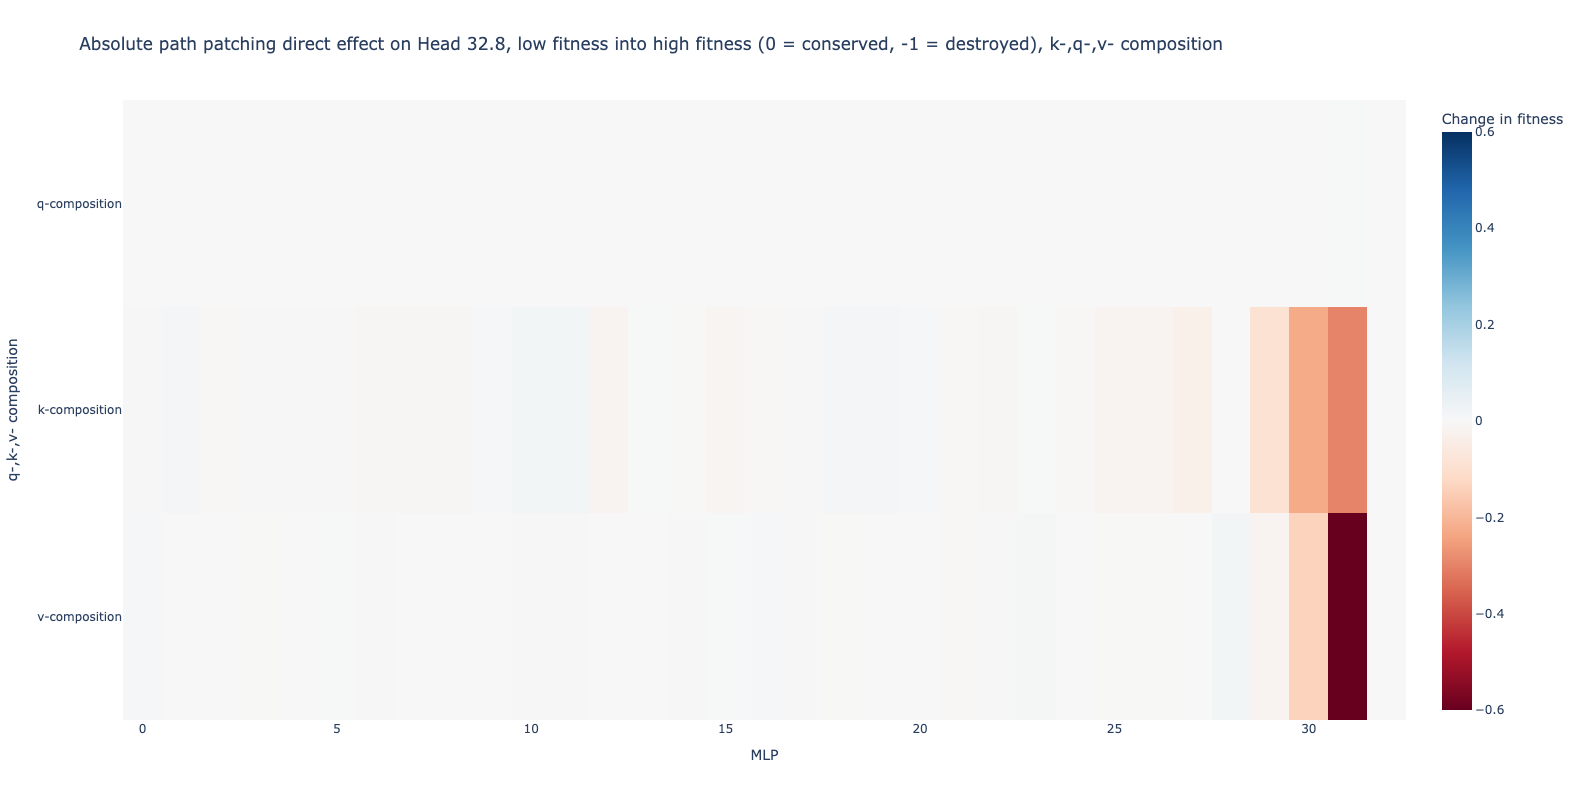

In [41]:
imshow(
    all_abs_mlp_patch_32_5_8_13_results_tensor,
    labels={"x": "MLP", "y": "q-,k-,v- composition", "color": "Change in fitness"},
    title="Absolute path patching direct effect on Head 32.8, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    width=1300,
    height=800,
    y = ["q-composition","k-composition","v-composition"], 
    range_color=(-0.6,0.6)
)

# Patching into MLP 31

In [30]:
hooked_esm.reset_hooks(including_permanent=False)
# clean = high fitness
# corr = low fitness

clean_toks = new_toks
corr_toks = orig_toks

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.0318608283996582


In [31]:
# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [35]:
head_path_patch_all_mlp = []
for mlp_idx in [31, 30]:
    head_path_patch_mlp_i = interp_utils.abs_path_patch_to_mlp(
        hooked_esm,
        receiver_mlps = [mlp_idx],
        orig_dataset = clean_toks,
        patching_metric = functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
        new_cache=new_cache,
        orig_cache=orig_cache,
        logit_id=logit_id,
        get_logit_hooked=get_logit_hooked,
    )
    head_path_patch_all_mlp.append(head_path_patch_mlp_i)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 620/620 [20:08<00:00,  1.95s/it]


In [36]:
head_path_patch_all_mlp_tensor = torch.stack(head_path_patch_all_mlp, dim=0)

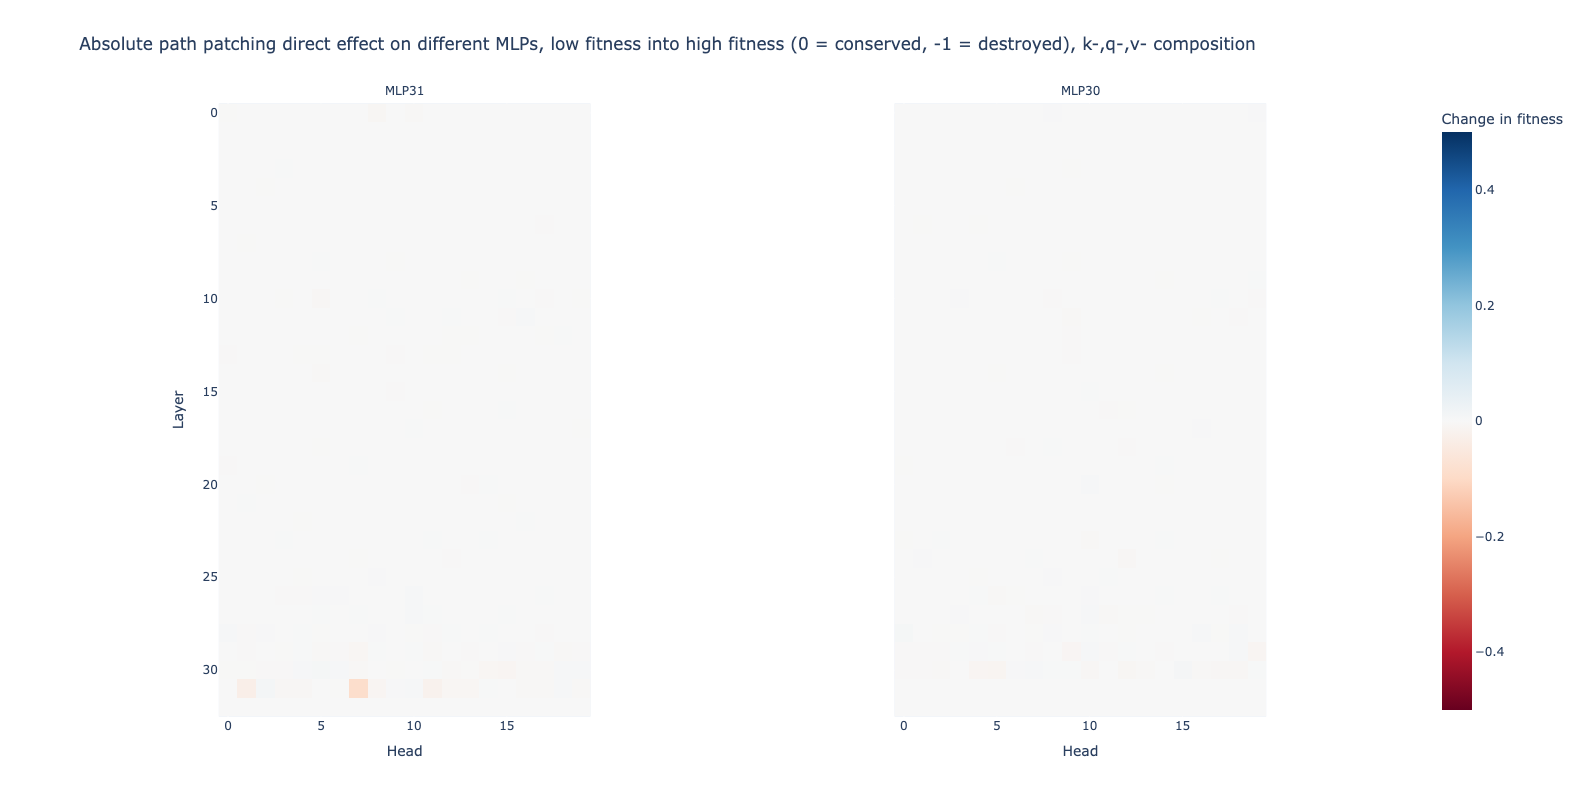

In [37]:
imshow(
    head_path_patch_all_mlp_tensor,
    labels={"x": "Head", "y": "Layer", "color": "Change in fitness"},
    title="Absolute path patching direct effect on different MLPs, low fitness into high fitness (0 = conserved, -1 = destroyed), k-,q-,v- composition",
    facet_labels=[f"MLP{mlp_idx}" for mlp_idx in [31, 30]],
    width=1600,
    height=800,
    facet_col=0,
    range_color=(-0.5,0.5)
)

# QK-circuit analysis (Eta seqs)

In [35]:
hooked_esm.reset_hooks(including_permanent=False)
attn_keys = [utils.get_act_name("pattern",x) for x in [31,32]]


# _, attn_cache_orig = hooked_esm.run_with_cache(orig_toks, names_filter=attn_keys)
# torch.cuda.empty_cache()
# _, attn_cache_mut = hooked_esm.run_with_cache(new_toks, names_filter=attn_keys)
# torch.cuda.empty_cache()

_, attn_cache_orig = hooked_esm.run_with_cache(eta_orig_toks, names_filter=attn_keys)
torch.cuda.empty_cache()
_, attn_cache_mut = hooked_esm.run_with_cache(eta_new_toks, names_filter=attn_keys)
torch.cuda.empty_cache()

In [36]:
attn_32_orig = attn_cache_orig[attn_keys[-1]]
attn_32_mut = attn_cache_mut[attn_keys[-1]]

attn_31_orig = attn_cache_orig[attn_keys[0]]
attn_31_mut = attn_cache_mut[attn_keys[0]]

In [37]:
heads_of_interest = [(32,5), (32,8), (32,13), (31,7), (31,17)]

attn_32_orig_cls = attn_32_orig[:, [x[1] for x in heads_of_interest if x[0] == 32], 0, :]
attn_32_mut_cls = attn_32_mut[:, [x[1] for x in heads_of_interest if x[0] == 32], 0, :]

attn_31_orig_cls = attn_31_orig[:, [x[1] for x in heads_of_interest if x[0] == 31], 456, :]
attn_31_mut_cls = attn_31_mut[:, [x[1] for x in heads_of_interest if x[0] == 31], 456, :]

attn_orig_cls = torch.cat([attn_32_orig_cls, attn_31_orig_cls], dim=1)
attn_mut_cls = torch.cat([attn_32_mut_cls, attn_31_mut_cls], dim=1)

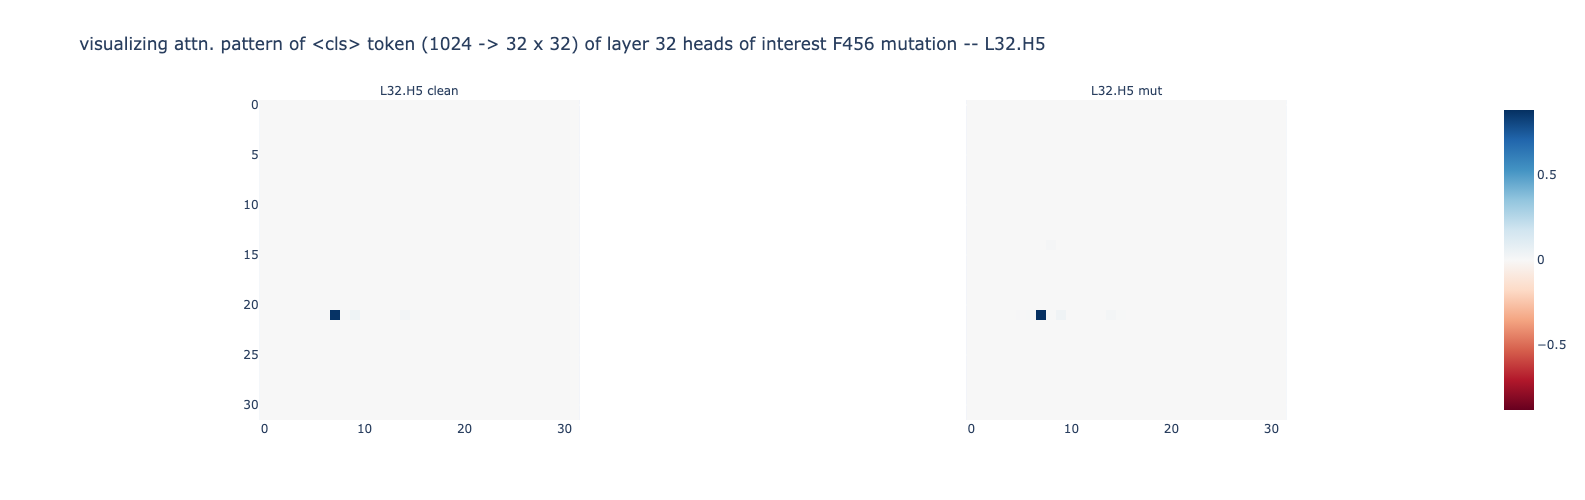

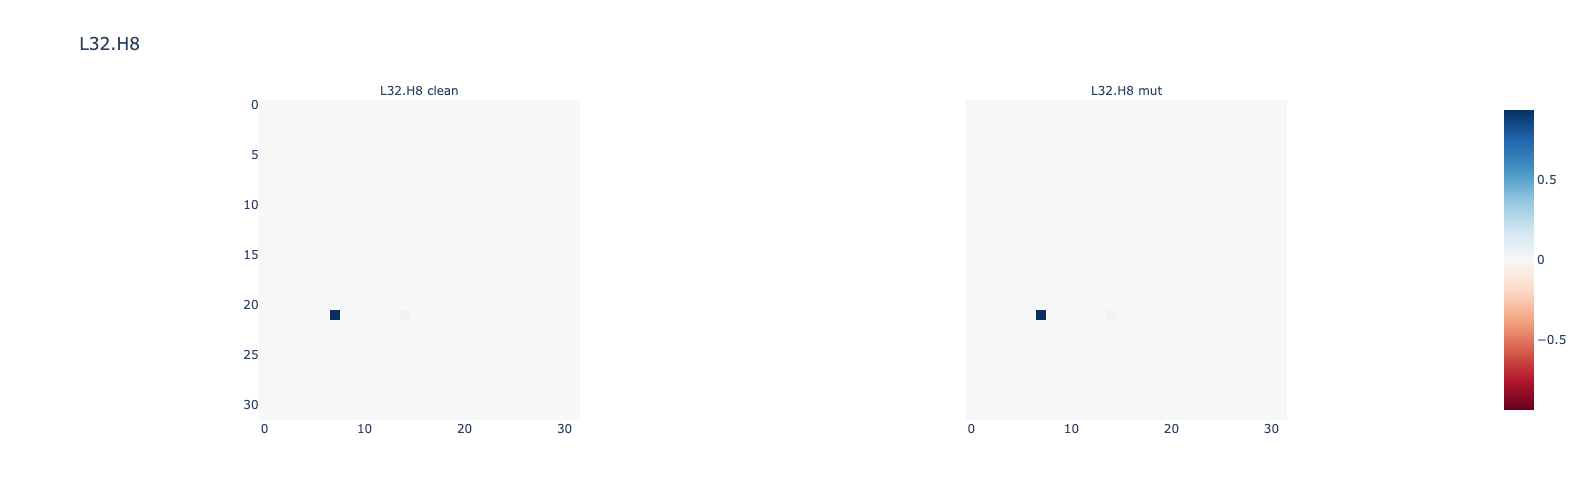

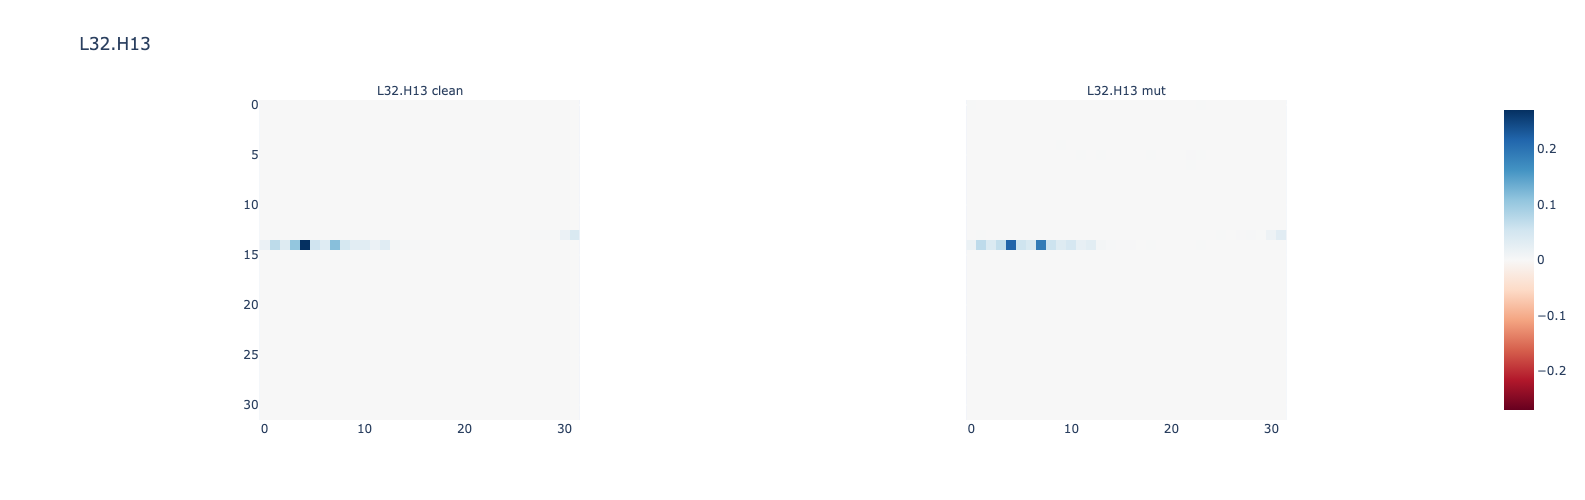

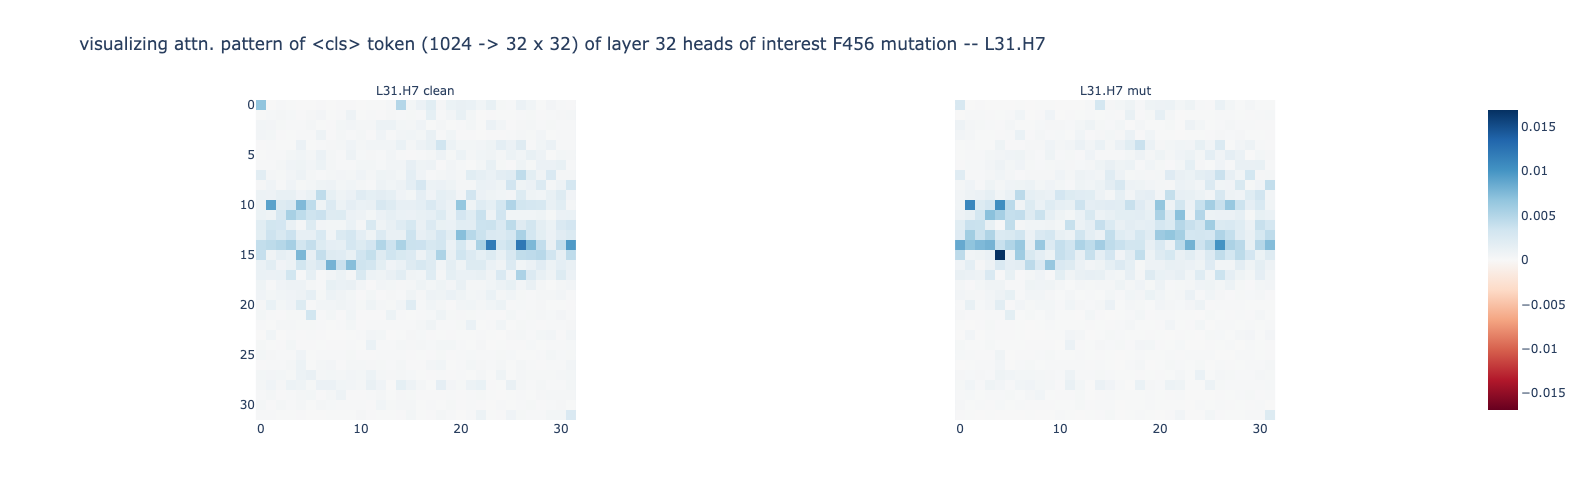

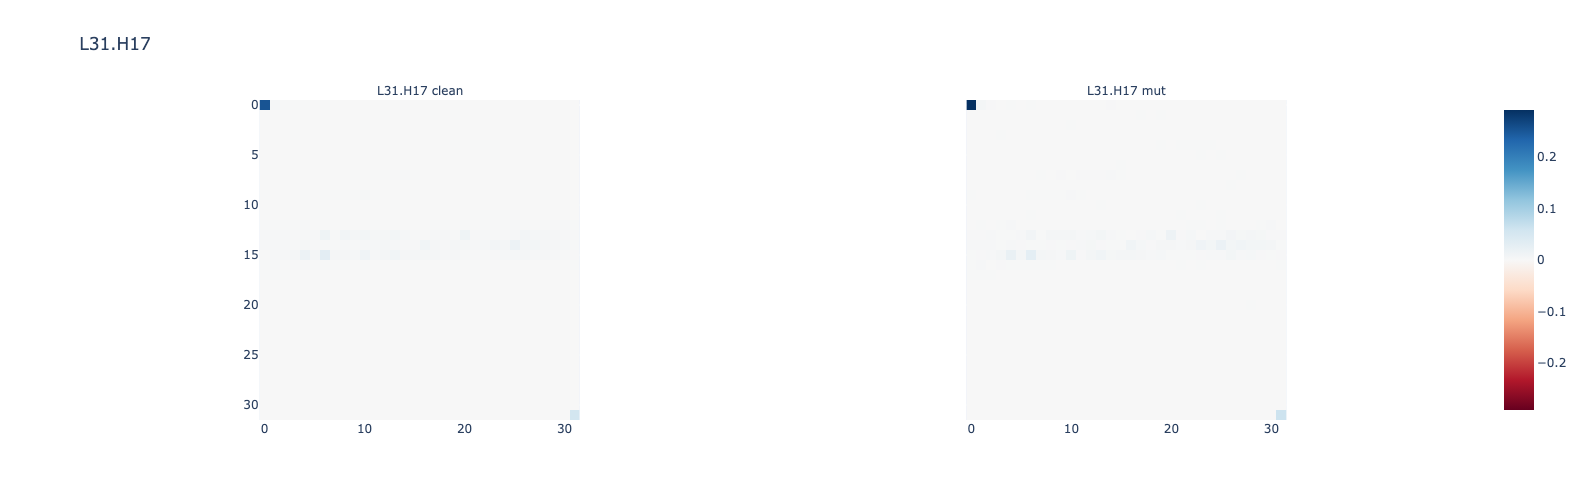

In [38]:
# randN = np.random.randint(low=0,high=101)
# randN = 50
# print(randN)
for i in range(len(heads_of_interest)):
    disp_tensor = torch.stack([attn_orig_cls[:,i,:].mean(dim=0), attn_mut_cls[:,i,:].mean(dim=0)], dim=0)
    # disp_tensor = torch.stack([attn_32_orig_cls[:,i,:][randN], attn_32_mut_cls[:,i,:][randN]], dim=0)
    disp_name = f"L{heads_of_interest[i][0]}.H{heads_of_interest[i][1]}"
    
    disp_width = 1100
    disp_height = 500
    if i == 0:
        fig = imshow(
            disp_tensor.view(-1,32,32),
            facet_col=0,
            x=np.arange(32),
            y=np.arange(32),
            width=disp_width, 
            height=disp_height, 
            facet_labels=[f"{disp_name} clean", f"{disp_name} mut"], 
            title=f"visualizing attn. pattern of <cls> token (1024 -> 32 x 32) of layer 32 heads of interest F456 mutation -- {disp_name}",
            return_fig=True,
        )
        fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 0 <- %{customdata}<br>Attn Prob. %{z}")
        fig.show()
    elif i == 3:
        fig = imshow(
            disp_tensor.view(-1,32,32),
            facet_col=0,
            x=np.arange(32),
            y=np.arange(32),
            width=disp_width, 
            height=disp_height, 
            facet_labels=[f"{disp_name} clean", f"{disp_name} mut"], 
            title=f"visualizing attn. pattern of <cls> token (1024 -> 32 x 32) of layer 32 heads of interest F456 mutation -- {disp_name}",
            return_fig=True,
        )
        fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 456 <- %{customdata}<br>Attn Prob. %{z}")
        fig.show()
    else:
        fig = imshow(
            disp_tensor.view(-1,32,32), 
            facet_col=0,
            x=np.arange(32),
            y=np.arange(32),
            width=disp_width, 
            height=disp_height, 
            facet_labels=[f"{disp_name} clean", f"{disp_name} mut"],
            title=disp_name,
            return_fig=True
        )
        fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 0 <- %{customdata}<br>Attn Prob. %{z}")
        fig.show()

# F456L QK-circuit (XBB.1.5 seqs)

In [35]:
hooked_esm.reset_hooks(including_permanent=False)
attn_keys = [utils.get_act_name("pattern",x) for x in [31,32]]


_, attn_cache_orig = hooked_esm.run_with_cache(orig_toks, names_filter=attn_keys)
torch.cuda.empty_cache()
_, attn_cache_mut = hooked_esm.run_with_cache(new_toks, names_filter=attn_keys)
torch.cuda.empty_cache()

In [36]:
attn_32_orig = attn_cache_orig[attn_keys[-1]]
attn_32_mut = attn_cache_mut[attn_keys[-1]]

attn_31_orig = attn_cache_orig[attn_keys[0]]
attn_31_mut = attn_cache_mut[attn_keys[0]]

In [37]:
heads_of_interest = [(32,5), (32,8), (32,13), (31,7), (31,17)]

attn_32_orig_cls = attn_32_orig[:, [x[1] for x in heads_of_interest if x[0] == 32], 0, :]
attn_32_mut_cls = attn_32_mut[:, [x[1] for x in heads_of_interest if x[0] == 32], 0, :]

attn_31_orig_cls = attn_31_orig[:, [x[1] for x in heads_of_interest if x[0] == 31], 456, :]
attn_31_mut_cls = attn_31_mut[:, [x[1] for x in heads_of_interest if x[0] == 31], 456, :]

attn_orig_cls = torch.cat([attn_32_orig_cls, attn_31_orig_cls], dim=1)
attn_mut_cls = torch.cat([attn_32_mut_cls, attn_31_mut_cls], dim=1)

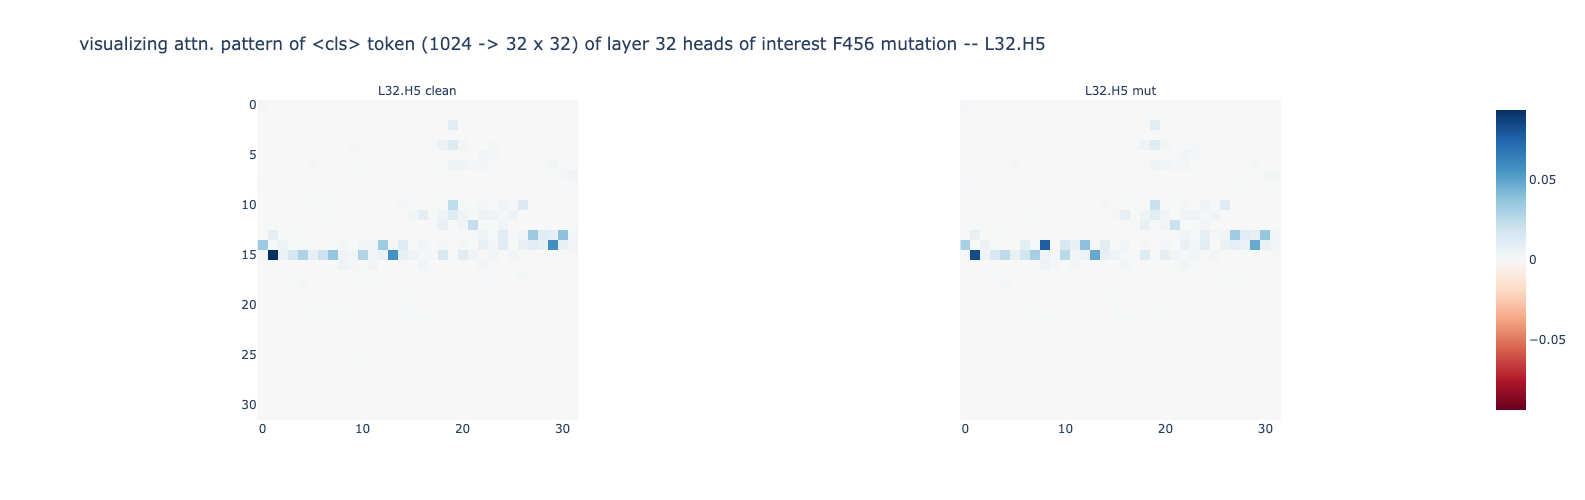

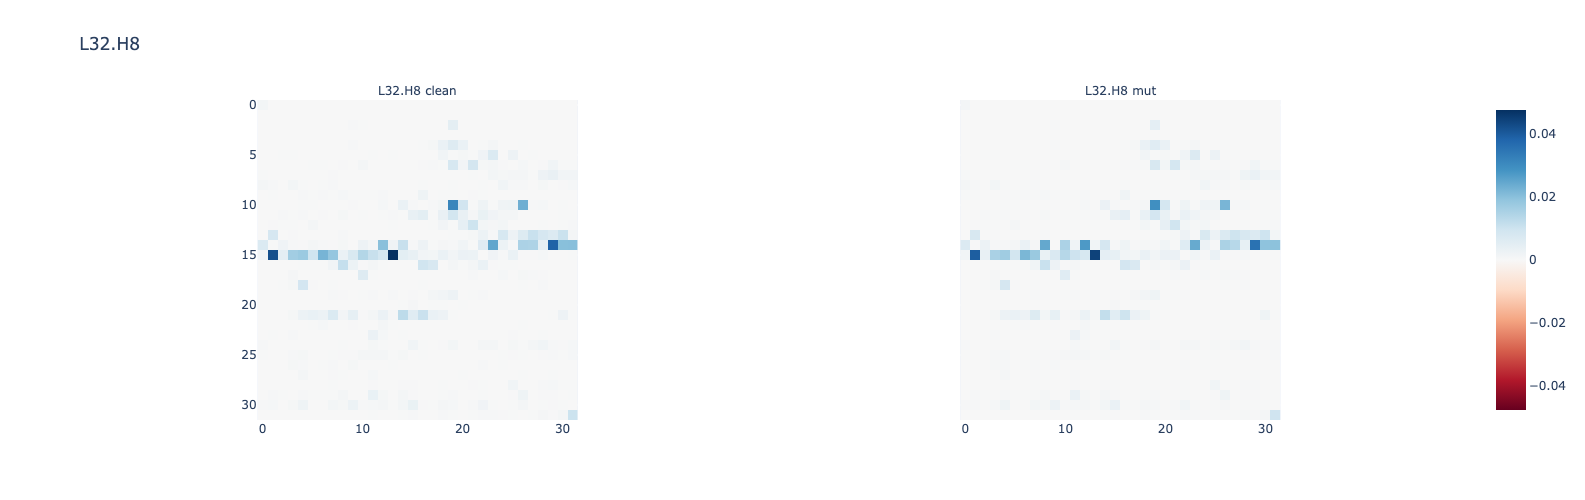

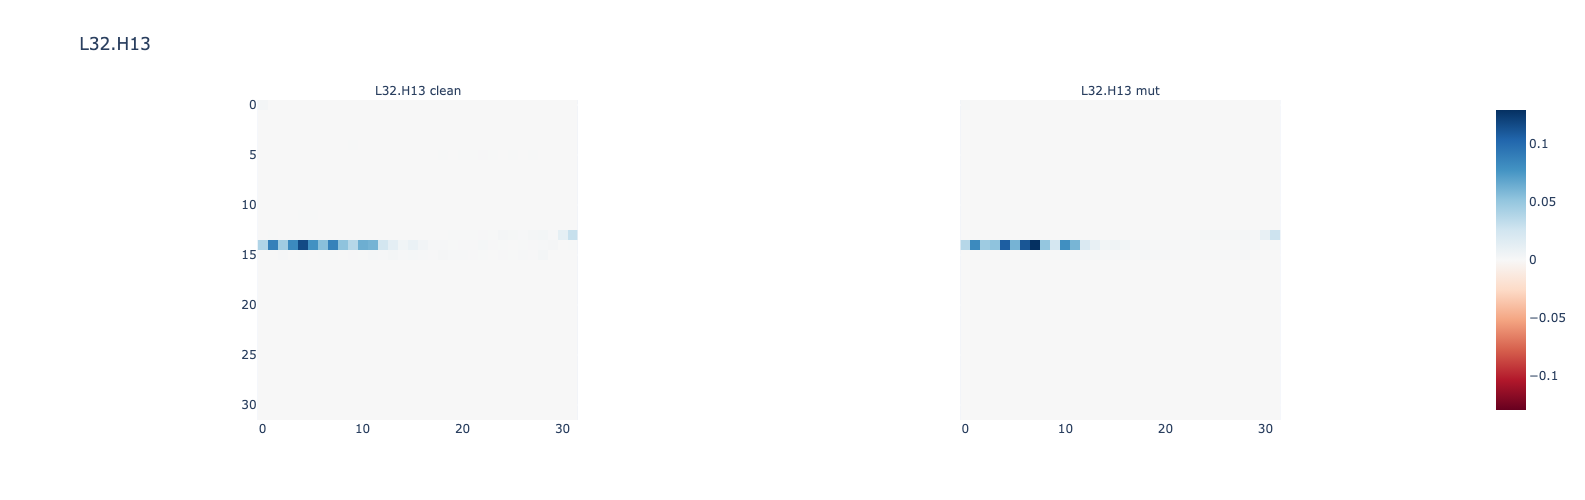

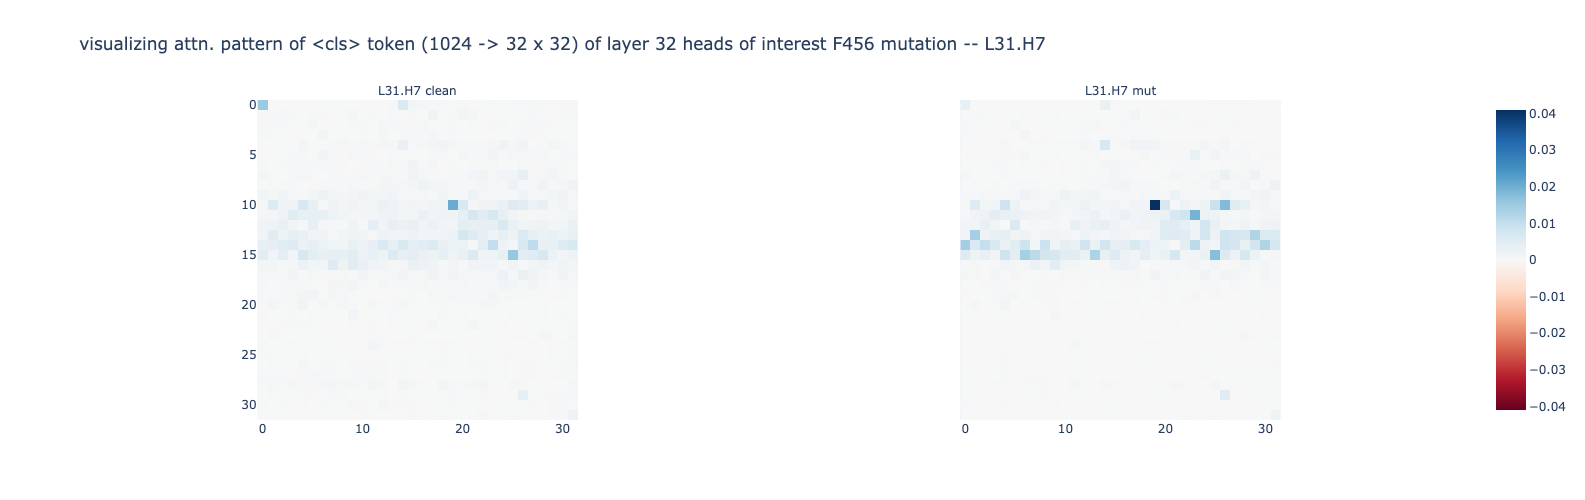

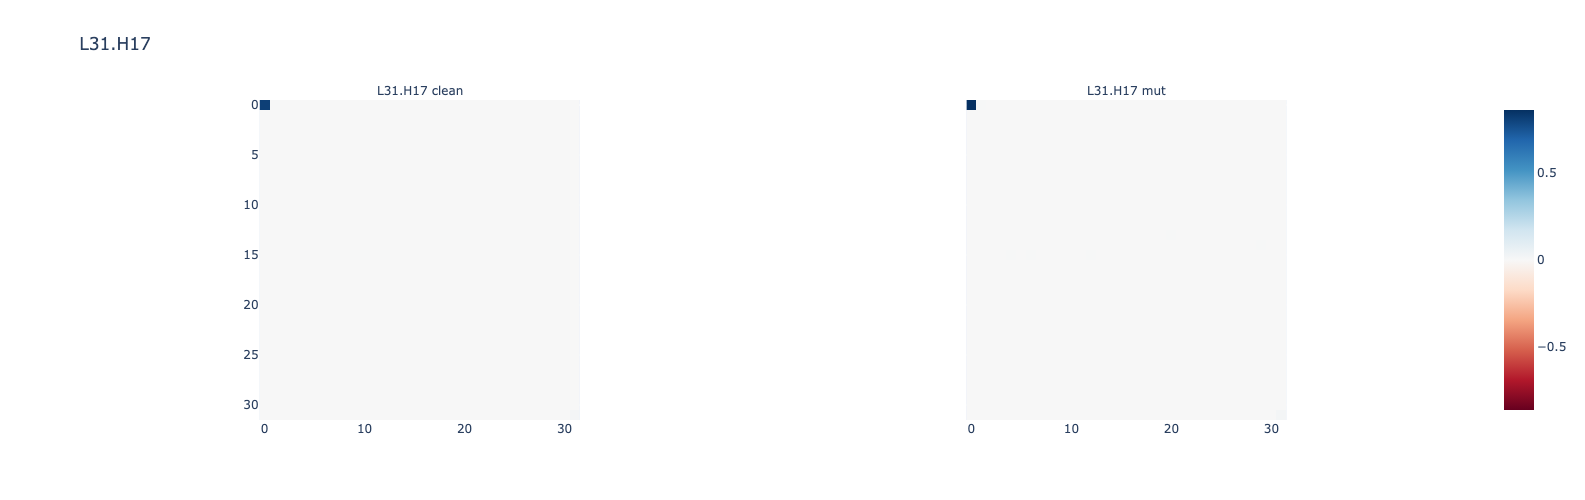

In [38]:
# randN = np.random.randint(low=0,high=101)
# randN = 50
# print(randN)
for i in range(len(heads_of_interest)):
    disp_tensor = torch.stack([attn_orig_cls[:,i,:].mean(dim=0), attn_mut_cls[:,i,:].mean(dim=0)], dim=0)
    # disp_tensor = torch.stack([attn_32_orig_cls[:,i,:][randN], attn_32_mut_cls[:,i,:][randN]], dim=0)
    disp_name = f"L{heads_of_interest[i][0]}.H{heads_of_interest[i][1]}"
    
    disp_width = 1100
    disp_height = 500
    if i == 0:
        fig = imshow(
            disp_tensor.view(-1,32,32),
            facet_col=0,
            x=np.arange(32),
            y=np.arange(32),
            width=disp_width, 
            height=disp_height, 
            facet_labels=[f"{disp_name} clean", f"{disp_name} mut"], 
            title=f"visualizing attn. pattern of <cls> token (1024 -> 32 x 32) of layer 32 heads of interest F456 mutation -- {disp_name}",
            return_fig=True,
        )
        fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 0 <- %{customdata}<br>Attn Prob. %{z}")
        fig.show()
    elif i == 3:
        fig = imshow(
            disp_tensor.view(-1,32,32),
            facet_col=0,
            x=np.arange(32),
            y=np.arange(32),
            width=disp_width, 
            height=disp_height, 
            facet_labels=[f"{disp_name} clean", f"{disp_name} mut"], 
            title=f"visualizing attn. pattern of <cls> token (1024 -> 32 x 32) of layer 32 heads of interest F456 mutation -- {disp_name}",
            return_fig=True,
        )
        fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 456 <- %{customdata}<br>Attn Prob. %{z}")
        fig.show()
    else:
        fig = imshow(
            disp_tensor.view(-1,32,32), 
            facet_col=0,
            x=np.arange(32),
            y=np.arange(32),
            width=disp_width, 
            height=disp_height, 
            facet_labels=[f"{disp_name} clean", f"{disp_name} mut"],
            title=disp_name,
            return_fig=True
        )
        fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 0 <- %{customdata}<br>Attn Prob. %{z}")
        fig.show()

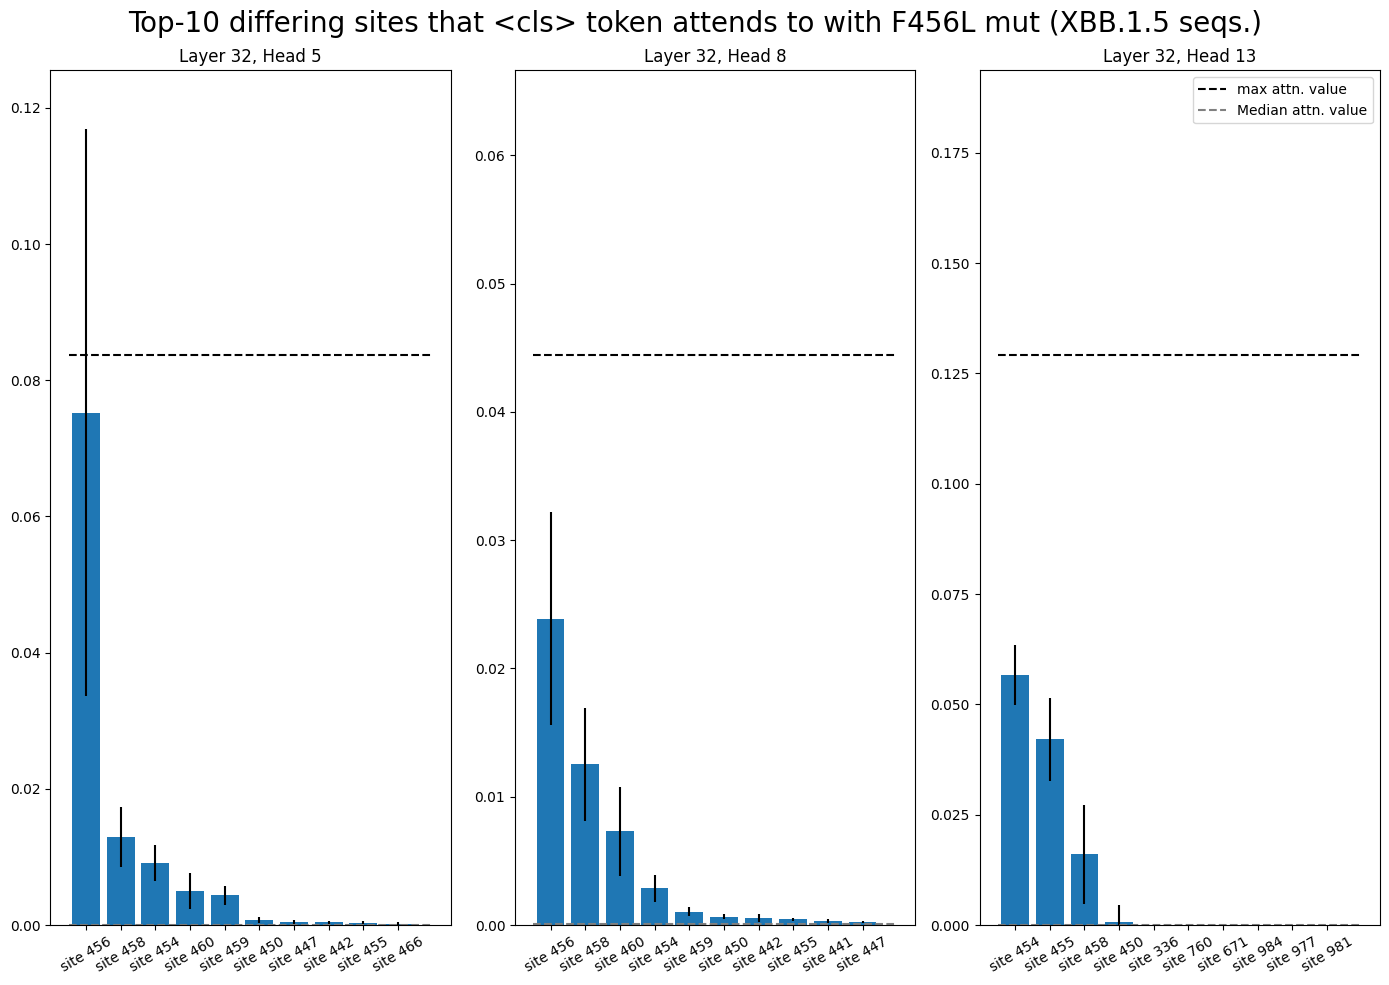

In [39]:
num_topk = 10
l32_heads = [x for x in heads_of_interest if x[0] == 32]
fig, ax = plt.subplots(1,3,figsize=(14,10))
diff_tok_idxs = attn_32_mut_cls - attn_32_orig_cls
max_diff_vals, max_diff_tok_idx = diff_tok_idxs.mean(dim=0).topk(k=num_topk,dim=-1)
max_attn_vals_mut = attn_32_mut_cls.mean(dim=0).max(dim=-1).values
median_attn_vals_mut = torch.median(attn_32_mut_cls.mean(dim=0), axis=-1).values
std_vals = torch.std(diff_tok_idxs, dim=0)

for i, ax_i in enumerate(ax):
    ax_i.bar(list(range(num_topk)), max_diff_vals[i,:].cpu(), yerr=std_vals[i,max_diff_tok_idx[i]].cpu())
    ax_i.set_xticks(list(range(num_topk)), labels=[f"site {x}" for x in max_diff_tok_idx[i,:].cpu()], rotation=30)
    ax_i.set_title(f"Layer 32, Head {l32_heads[i][1]}")
    ax_i.plot([-0.5,num_topk], [max_attn_vals_mut[i].cpu() for _ in range(2)], linestyle="dashed", label="max attn. value", color="black")
    ax_i.plot([-0.5,num_topk], [median_attn_vals_mut[i].cpu() for _ in range(2)], linestyle="dashed", label="Median attn. value", color="grey")
    ax_i.set_ylim([0, max_attn_vals_mut[i].cpu() * 1.5])
    if i == len(ax) - 1:
        ax_i.legend()
fig.suptitle(f"Top-{num_topk} differing sites that <cls> token attends to with F456L mut (XBB.1.5 seqs.)", fontsize=20)
plt.tight_layout()
plt.show()